Raw data audit

We check: 

    1. Dataset shape, 
    2. column types, 
    3. target distribution,
    4. zero-value counts in implausible fields (Glucose, BP, SkinThickness, Insulin, BMI)
    5. and why those zeros need imputation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


1. Load Dataset and check dataset shape and column types

In [9]:
diabetes = pd.read_csv('../data/diabetes.csv')
print(f'Dataset shape: {diabetes.shape}')
print(f'Column types: {diabetes.dtypes}')

Dataset shape: (768, 9)
Column types: Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


2. Check for target distribution 

In [11]:
diabetes['Outcome'].describe()

count    768.000000
mean       0.348958
std        0.476951
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: Outcome, dtype: float64

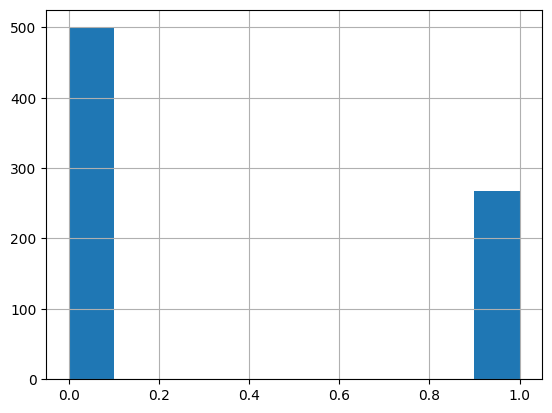

In [12]:
diabetes['Outcome'].hist()
plt.show()

In [13]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
(diabetes[cols] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In situations such as these, the zeros need imputation as for example, you can not have 0 blood glucose and be alive, so the zero = missing. Having a BloodPressure of 0 mmHg is impossible, so the zero = missing. Having a 0 mm skinfold doesn't make sense, so the zero is missing. Having 0 insulin is unrealistic, so the zero is missing. Having a 0 BMI is impossible, so the zero is missing. 